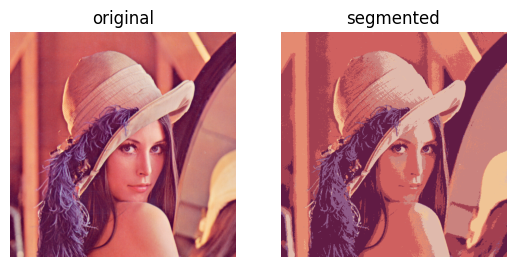

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('./Lena.png').astype(np.float32) / 255.
image_lab = cv2.cvtColor(image, cv2.COLOR_BGR2Lab)

data = image_lab.reshape((-1, 3))

num_classes = 8
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 50, 0.1)
_, labels, centers = cv2.kmeans(data, num_classes, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

segmented_lab = centers[labels.flatten()].reshape(image.shape)
segmented = cv2.cvtColor(segmented_lab, cv2.COLOR_Lab2RGB)

plt.subplot(121)
plt.axis('off')
plt.title('original')
plt.imshow(image[:, :, [2, 1, 0]])
plt.subplot(122)
plt.axis('off')
plt.title('segmented')
plt.imshow(segmented)
plt.show()

In [2]:
import cv2
import numpy as np
from random import randint

img = cv2.imread('./Lena.png')
show_img = np.copy(img)

seeds = np.full(img.shape[0:2], 0, np.int32)
segmentation = np.full(img.shape, 0, np.uint8)

n_seeds = 9

colors = []
for m in range(n_seeds):
    colors.append((255 * m / n_seeds, randint(0, 255), randint(0, 255)))

mouse_pressed = False
current_seed = 1
seeds_updated = False

def mouse_callback(event, x, y, flags, param):
    global mouse_pressed, seeds_updated

    if event == cv2.EVENT_LBUTTONDOWN:
        mouse_pressed = True
        cv2.circle(seeds, (x, y), 5, (current_seed), cv2.FILLED)
        cv2.circle(show_img, (x, y), 5, colors[current_seed - 1], cv2.FILLED)
        seeds_updated = True

    elif event == cv2.EVENT_MOUSEMOVE:
        if mouse_pressed:
            cv2.circle(seeds, (x, y), 5, (current_seed), cv2.FILLED)
            cv2.circle(show_img, (x, y), 5, colors[current_seed - 1], cv2.FILLED)
            seeds_updated = True

    elif event == cv2.EVENT_LBUTTONUP:
        mouse_pressed = False

cv2.namedWindow('image')
cv2.setMouseCallback('image', mouse_callback)

while True:
    cv2.imshow('segmentation', segmentation)
    cv2.imshow('image', show_img)

    k = cv2.waitKey(1)

    if k == 27:
        break
    elif k == ord('c'):
        show_img = np.copy(img)
        seeds = np.full(img.shape[0:2], 0, np.int32)
        segmentation = np.full(img.shape, 0, np.uint8)
    elif k > 0 and chr(k).isdigit():
        n = int(chr(k))
        if 1 <= n <= n_seeds and not mouse_pressed:
            current_seed = n

    if seeds_updated and not mouse_pressed:
        seeds_copy = np.copy(seeds)
        cv2.watershed(img, seeds_copy)
        segmentation = np.full(img.shape, 0, np.uint8)
        for m in range(n_seeds):
            segmentation[seeds_copy == (m + 1)] = colors[m]

        seeds_updated = False

cv2.destroyAllWindows()

In [3]:
import cv2
import numpy as np

img = cv2.imread('./Lena.png', cv2.IMREAD_COLOR)
show_img = np.copy(img)

mouse_pressed = False
y = x = w = h = 0

def mouse_callback(event, _x, _y, flags, param):
    global show_img, x, y, w, h, mouse_pressed

    if event == cv2.EVENT_LBUTTONDOWN:
        mouse_pressed = True
        x, y = _x, _y
        show_img = np.copy(img)

    elif event == cv2.EVENT_MOUSEMOVE:
        if mouse_pressed:
            show_img = np.copy(img)
            cv2.rectangle(show_img, (x, y),
                          (_x, _y), (0, 255, 0), 3)

    elif event == cv2.EVENT_LBUTTONUP:
        mouse_pressed = False
        w, h = _x - x, _y - y

cv2.namedWindow('image')
cv2.setMouseCallback('image', mouse_callback)

while True:
    cv2.imshow('image', show_img)
    k = cv2.waitKey(1)

    if k == ord('a') and not mouse_pressed:
        if w * h > 0:
            break

cv2.destroyAllWindows()

labels = np.zeros(img.shape[:2], np.uint8)
labels, bgdModel, fgdModel = cv2.grabCut(img, labels,
    (x, y, w, h), None, None, 5, cv2.GC_INIT_WITH_RECT)

show_img = np.copy(img)
show_img[(labels == cv2.GC_PR_BGD) | (labels == cv2.GC_BGD)] //= 3

cv2.imshow('image', show_img)
cv2.waitKey()
cv2.destroyAllWindows()

label = cv2.GC_BGD
lbl_clrs = {cv2.GC_BGD: (0, 0, 0), cv2.GC_FGD: (255, 255, 255)}

def mouse_callback(event, x, y, flags, param):
    global mouse_pressed

    if event == cv2.EVENT_LBUTTONDOWN:
        mouse_pressed = True
        cv2.circle(labels, (x, y), 5, label, cv2.FILLED)
        cv2.circle(show_img, (x, y), 5, lbl_clrs[label], cv2.FILLED)

    elif event == cv2.EVENT_MOUSEMOVE:
        if mouse_pressed:
            cv2.circle(labels, (x, y), 5, label, cv2.FILLED)
            cv2.circle(show_img, (x, y), 5, lbl_clrs[label], cv2.FILLED)

    elif event == cv2.EVENT_LBUTTONUP:
        mouse_pressed = False

cv2.namedWindow('image')
cv2.setMouseCallback('image', mouse_callback)

while True:
    cv2.imshow('image', show_img)
    k = cv2.waitKey(1)

    if k == ord('a') and not mouse_pressed:
        break
    elif k == ord('l'):
        label = cv2.GC_FGD - label

cv2.destroyAllWindows()

labels, bgdModel, fgdModel = cv2.grabCut(img, labels, None,
    bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_MASK)

show_img = np.copy(img)
show_img[(labels == cv2.GC_PR_BGD) | (labels == cv2.GC_BGD)] //= 3

cv2.imshow('image', show_img)
cv2.waitKey()
cv2.destroyAllWindows()


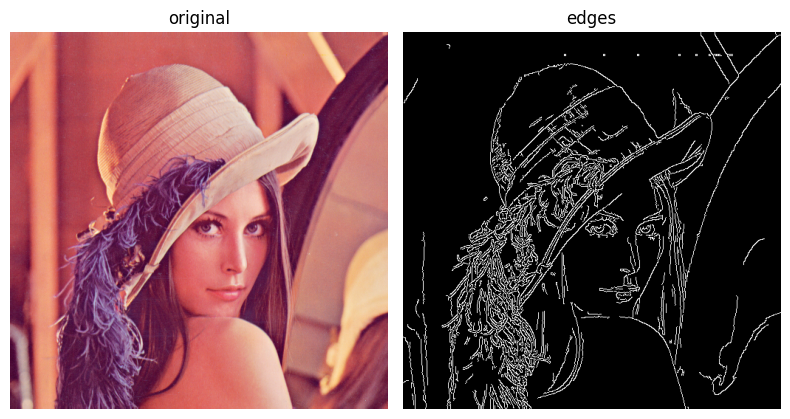

In [4]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('./Lena.png')

edges = cv2.Canny(image, 200, 100)

plt.figure(figsize=(8,5))
plt.subplot(121)
plt.axis('off')
plt.title('original')
plt.imshow(image[:, :, [2, 1, 0]])
plt.subplot(122)
plt.axis('off')
plt.title('edges')
plt.imshow(edges, cmap='gray')
plt.tight_layout()
plt.show()

Detected line: (99 401) (372 353)
Detected circle: center=(200.5 200.5), radius=52.29999923706055


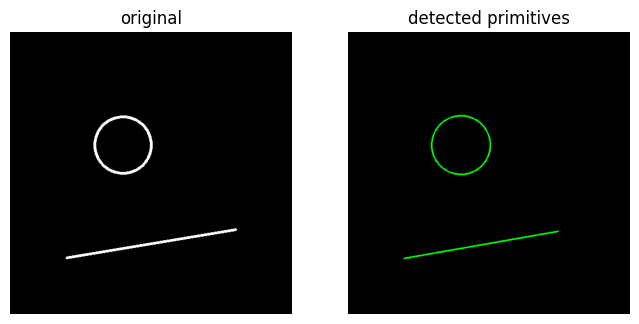

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = np.zeros((500, 500), np.uint8)

cv2.circle(img, (200, 200), 50, 255, 3)
cv2.line(img, (100, 400), (400, 350), 255, 3)

circles = cv2.HoughCircles(img, cv2.HOUGH_GRADIENT, 1, 15, param1=200, param2=30)[0]

lines = cv2.HoughLinesP(img, 1, np.pi/180, 100, 100, 10)[0]

dbg_img = np.zeros((img.shape[0], img.shape[1], 3), np.uint8)
for x1, y1, x2, y2 in lines:
    print('Detected line: ({} {}) ({} {})'.format(x1, y1, x2, y2))
    cv2.line(dbg_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

for c in circles:
    print('Detected circle: center=({} {}), radius={}'.format(c[0], c[1], c[2]))
    cv2.circle(dbg_img, (int(c[0]), int(c[1])), int(c[2]), (0, 255, 0), 2)

plt.figure(figsize=(8,4))
plt.subplot(121)
plt.title('original')
plt.axis('off')
plt.imshow(img, cmap='gray')
plt.subplot(122)
plt.title('detected primitives')
plt.axis('off')
plt.imshow(dbg_img)
plt.show()

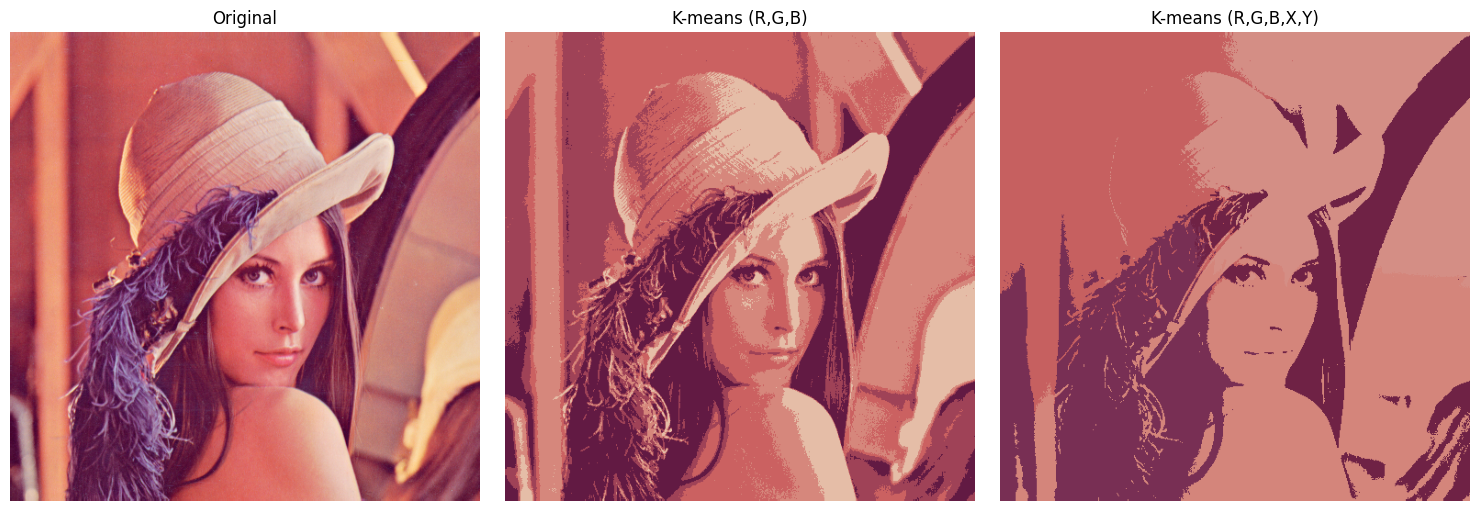

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('./Lena.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, c = img.shape
K = 5

# === (R, G, B)만 사용한 K-means ===
pixels_rgb = img_rgb.reshape(-1, 3).astype(np.float32)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
_, labels_rgb, centers_rgb = cv2.kmeans(pixels_rgb, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

centers_rgb = np.uint8(centers_rgb)
result_rgb = centers_rgb[labels_rgb.flatten()].reshape(img_rgb.shape)

# === (R, G, B, X, Y)를 사용한 K-means ===
xx, yy = np.meshgrid(np.arange(w), np.arange(h))
xx = xx.reshape(-1, 1).astype(np.float32)
yy = yy.reshape(-1, 1).astype(np.float32)

# 좌표를 색상 범위에 맞게 정규화
xx_norm = xx / w * 255
yy_norm = yy / h * 255

pixels_rgbxy = np.hstack([pixels_rgb, xx_norm, yy_norm])

_, labels_rgbxy, centers_rgbxy = cv2.kmeans(pixels_rgbxy, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

centers_rgbxy_color = np.uint8(centers_rgbxy[:, :3])
result_rgbxy = centers_rgbxy_color[labels_rgbxy.flatten()].reshape(img_rgb.shape)

# === 결과 비교 출력 ===
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(result_rgb)
plt.title('K-means (R,G,B)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(result_rgbxy)
plt.title('K-means (R,G,B,X,Y)')
plt.axis('off')

plt.tight_layout()
plt.show()

In [9]:
import cv2
import numpy as np

img = cv2.imread('./Lena.png', cv2.IMREAD_COLOR)
show_img = np.copy(img)

mouse_pressed = False
y = x = w = h = 0

def mouse_callback_rect(event, _x, _y, flags, param):
    global show_img, x, y, w, h, mouse_pressed

    if event == cv2.EVENT_LBUTTONDOWN:
        mouse_pressed = True
        x, y = _x, _y
        show_img = np.copy(img)

    elif event == cv2.EVENT_MOUSEMOVE:
        if mouse_pressed:
            show_img = np.copy(img)
            cv2.rectangle(show_img, (x, y),
                          (_x, _y), (0, 255, 0), 3)

    elif event == cv2.EVENT_LBUTTONUP:
        mouse_pressed = False
        w, h = _x - x, _y - y

# Step 1: ROI 사각형 선택
cv2.namedWindow('image')
cv2.setMouseCallback('image', mouse_callback_rect)

while True:
    cv2.imshow('image', show_img)
    k = cv2.waitKey(1)

    if k == ord('a') and not mouse_pressed:
        if w * h > 0:
            break

cv2.destroyAllWindows()

# Step 2: 초기 GrabCut 실행
labels = np.zeros(img.shape[:2], np.uint8)
labels, bgdModel, fgdModel = cv2.grabCut(img, labels,
    (x, y, w, h), None, None, 5, cv2.GC_INIT_WITH_RECT)

show_img = np.copy(img)
show_img[(labels == cv2.GC_PR_BGD) | (labels == cv2.GC_BGD)] //= 3

cv2.imshow('image', show_img)
cv2.waitKey()
cv2.destroyAllWindows()

# Step 3: 사용자 수정 반복
label = cv2.GC_BGD
lbl_clrs = {cv2.GC_BGD: (0, 0, 0), cv2.GC_FGD: (255, 255, 255)}

def mouse_callback_mask(event, x, y, flags, param):
    global mouse_pressed

    if event == cv2.EVENT_LBUTTONDOWN:
        mouse_pressed = True
        cv2.circle(labels, (x, y), 5, label, cv2.FILLED)
        cv2.circle(show_img, (x, y), 5, lbl_clrs[label], cv2.FILLED)

    elif event == cv2.EVENT_MOUSEMOVE:
        if mouse_pressed:
            cv2.circle(labels, (x, y), 5, label, cv2.FILLED)
            cv2.circle(show_img, (x, y), 5, lbl_clrs[label], cv2.FILLED)

    elif event == cv2.EVENT_LBUTTONUP:
        mouse_pressed = False

cv2.namedWindow('image')
cv2.setMouseCallback('image', mouse_callback_mask)

while True:
    cv2.imshow('image', show_img)
    k = cv2.waitKey(1)

    if k == ord('a') and not mouse_pressed:
        break
    elif k == ord('l'):
        label = cv2.GC_FGD - label

cv2.destroyAllWindows()

# Step 4: 수정된 마스크로 GrabCut 재실행
labels, bgdModel, fgdModel = cv2.grabCut(img, labels, None,
    bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_MASK)

show_img = np.copy(img)
show_img[(labels == cv2.GC_PR_BGD) | (labels == cv2.GC_BGD)] //= 3

cv2.imshow('image', show_img)
cv2.waitKey()
cv2.destroyAllWindows()
